In [29]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway, kruskal

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [ ]:
#Load dataset
trades = pd.read_csv("dataset/historical_data.csv")
sentiment = pd.read_csv("dataset/fear_greed_index.csv")

print("Trades shape:", trades.shape)
print("Sentiment shape:", sentiment.shape)

print("\nTrades columns:")
print(trades.columns)

print("\nSentiment columns:")
print(sentiment.columns)

Trades shape: (211224, 16)
Sentiment shape: (2644, 4)

Trades columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

Sentiment columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [53]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   account           211224 non-null  object        
 1   coin              211224 non-null  object        
 2   execution_price   211224 non-null  float64       
 3   size_tokens       211224 non-null  float64       
 4   size_usd          211224 non-null  float64       
 5   side              211224 non-null  object        
 6   timestamp_ist     79225 non-null   datetime64[ns]
 7   start_position    211224 non-null  float64       
 8   direction         211224 non-null  object        
 9   closed_pnl        211224 non-null  float64       
 10  transaction_hash  211224 non-null  object        
 11  order_id          211224 non-null  int64         
 12  crossed           211224 non-null  bool          
 13  fee               211224 non-null  float64       
 14  trad

In [54]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 82.8+ KB


In [31]:
# Data Cleaning 
# standardize column names
trades.columns = [c.strip().lower().replace(" ", "_") for c in trades.columns]
sentiment.columns = [c.strip().lower().replace(" ", "_") for c in sentiment.columns]

# convert datetime columns
trades["timestamp_ist"] = pd.to_datetime(trades["timestamp_ist"], errors="coerce")
sentiment["date"] = pd.to_datetime(sentiment["date"], errors="coerce")

# create trade date for merge
trades["date"] = pd.to_datetime(trades["timestamp_ist"].dt.date)

# numeric conversion
numeric_cols = ["execution_price", "size_tokens", "size_usd", "closed_pnl", "fee"]
for col in numeric_cols:
    if col in trades.columns:
        trades[col] = pd.to_numeric(trades[col], errors="coerce")

# clean text columns
if "side" in trades.columns:
    trades["side"] = trades["side"].astype(str).str.strip().str.lower()

if "coin" in trades.columns:
    trades["coin"] = trades["coin"].astype(str).str.strip()

if "classification" in sentiment.columns:
    sentiment["classification"] = sentiment["classification"].astype(str).str.strip()

print(trades.head())
print(sentiment.head())

                                      account  coin  execution_price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   size_tokens  size_usd side       timestamp_ist  start_position direction  \
0       986.87   7872.16  buy 2024-02-12 22:50:00        0.000000       Buy   
1        16.00    127.68  buy 2024-02-12 22:50:00      986.524596       Buy   
2       144.09   1150.63  buy 2024-02-12 22:50:00     1002.518996       Buy   
3       142.98   1142.04  buy 2024-02-12 22:50:00     1146.558564       Buy   
4         8.73     69.75  buy 2024-02-12 22:50:00     1289.488521       Buy   

   closed_pnl                                   transaction_hash     order_id  \
0         0

In [32]:
# Merge Dataset
data = trades.merge(
    sentiment[["date", "classification"]],
    on="date",
    how="left"
)

print("Merged shape:", data.shape)
print(data[["date", "classification"]].head())
print(data["classification"].value_counts(dropna=False))

Merged shape: (211224, 18)
        date classification
0 2024-02-12          Greed
1 2024-02-12          Greed
2 2024-02-12          Greed
3 2024-02-12          Greed
4 2024-02-12          Greed
classification
NaN              175360
Fear              13869
Greed             11292
Extreme Greed      5621
Neutral            2756
Extreme Fear       2326
Name: count, dtype: int64


In [33]:
data = data.dropna(subset=["classification"]).copy()

In [34]:
data = data[data["closed_pnl"].notna()].copy()
data = data[data["closed_pnl"] != 0].copy()

print("Filtered shape:", data.shape)

Filtered shape: (17929, 18)


In [35]:
# feature Engineering
# profit indicator
data["is_profit"] = (data["closed_pnl"] > 0).astype(int)

# loss indicator
data["is_loss"] = (data["closed_pnl"] < 0).astype(int)

# absolute trade size
data["abs_size_usd"] = data["size_usd"].abs()

# hour and weekday
data["hour"] = data["timestamp_ist"].dt.hour
data["weekday"] = data["timestamp_ist"].dt.day_name()

# pnl per unit size
data["pnl_to_size_ratio"] = data["closed_pnl"] / data["abs_size_usd"]
data["pnl_to_size_ratio"] = data["pnl_to_size_ratio"].replace([np.inf, -np.inf], np.nan)

#### Exploratory Data Analysis


In [36]:
# Summary Table
summary = data.groupby("classification").agg(
    trades=("closed_pnl", "count"),
    total_pnl=("closed_pnl", "sum"),
    avg_pnl=("closed_pnl", "mean"),
    median_pnl=("closed_pnl", "median"),
    win_rate=("is_profit", "mean"),
    avg_trade_size=("abs_size_usd", "mean"),
    total_volume=("abs_size_usd", "sum")
).reset_index()

summary["win_rate"] = summary["win_rate"] * 100
summary = summary.sort_values("total_pnl", ascending=False)

print(summary)

  classification  trades     total_pnl     avg_pnl  median_pnl   win_rate  \
2           Fear    6215  1.779226e+06  286.279257   11.949000  85.197104   
1  Extreme Greed    3416  1.156894e+06  338.669109   15.041160  91.042155   
3          Greed    5804  6.096325e+05  105.036618   12.221253  84.769125   
4        Neutral    1671  7.465674e+04   44.677883    4.530500  81.627768   
0   Extreme Fear     823  4.399937e+03    5.346217    1.332027  82.746051   

   avg_trade_size  total_volume  
2     6216.138882   38633303.15  
1     2730.718328    9328133.81  
3     5370.293568   31169183.87  
4     3649.992843    6099138.04  
0     4023.293256    3311170.35  


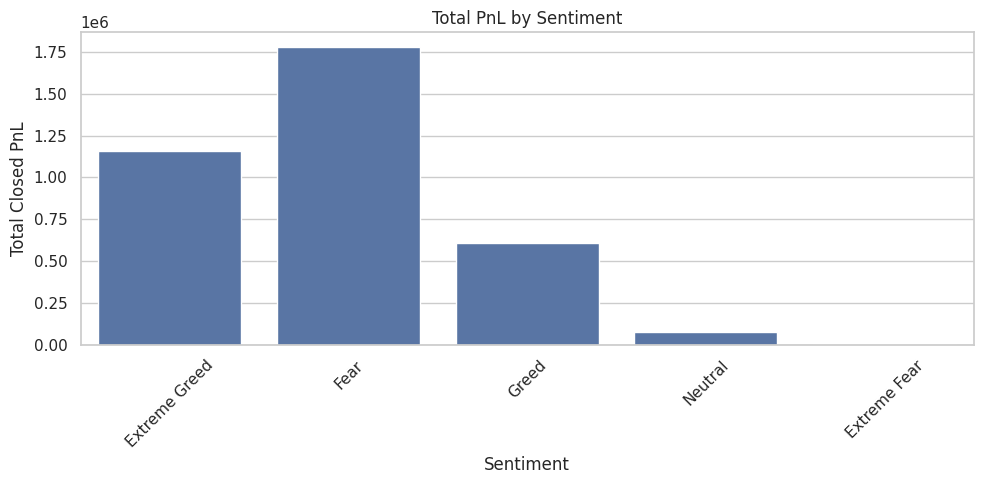

In [37]:
# Total PnL by sentiment
plt.figure(figsize=(10, 5))
sns.barplot(data=data, x="classification", y="closed_pnl", estimator=sum, errorbar=None)
plt.title("Total PnL by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Total Closed PnL")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

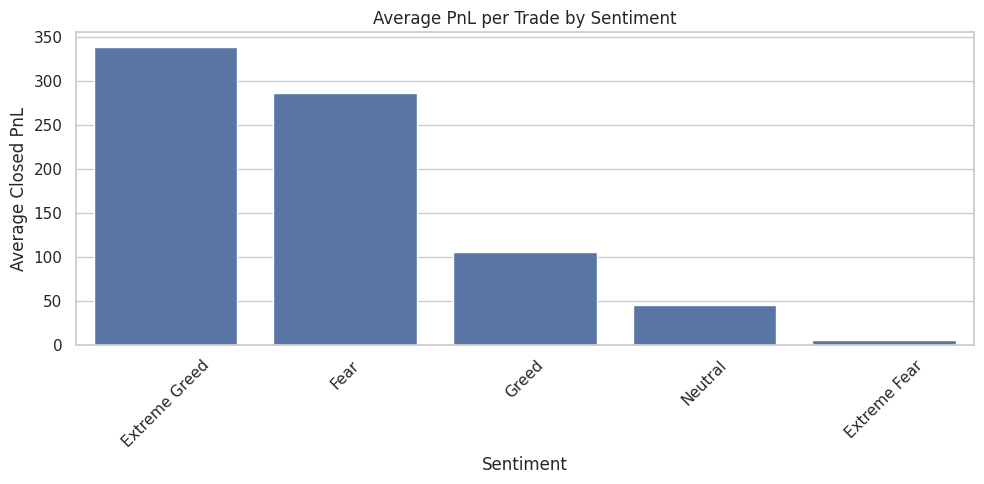

In [38]:
# Average PnL by sentiment
plt.figure(figsize=(10, 5))
sns.barplot(data=data, x="classification", y="closed_pnl", estimator=np.mean, errorbar=None)
plt.title("Average PnL per Trade by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

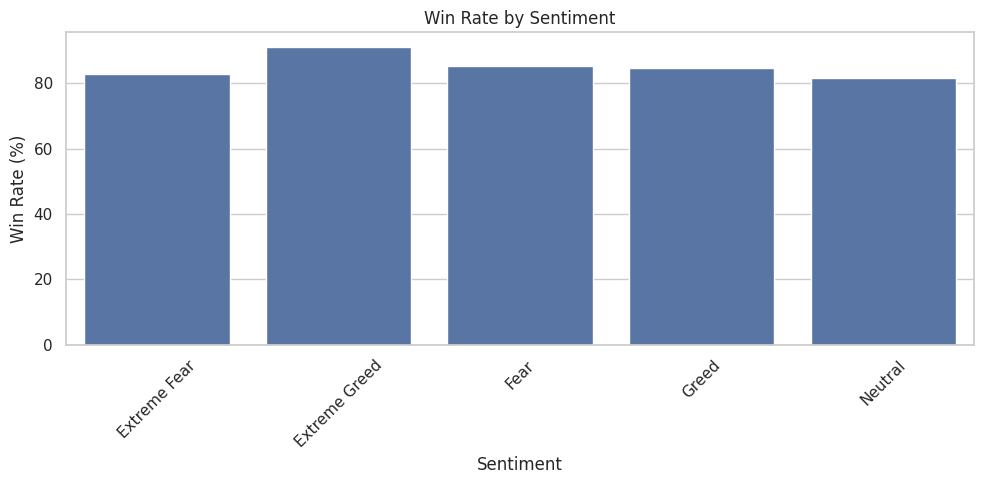

In [39]:
# Win rate by sentiment
winrate = data.groupby("classification")["is_profit"].mean().mul(100).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=winrate, x="classification", y="is_profit")
plt.title("Win Rate by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

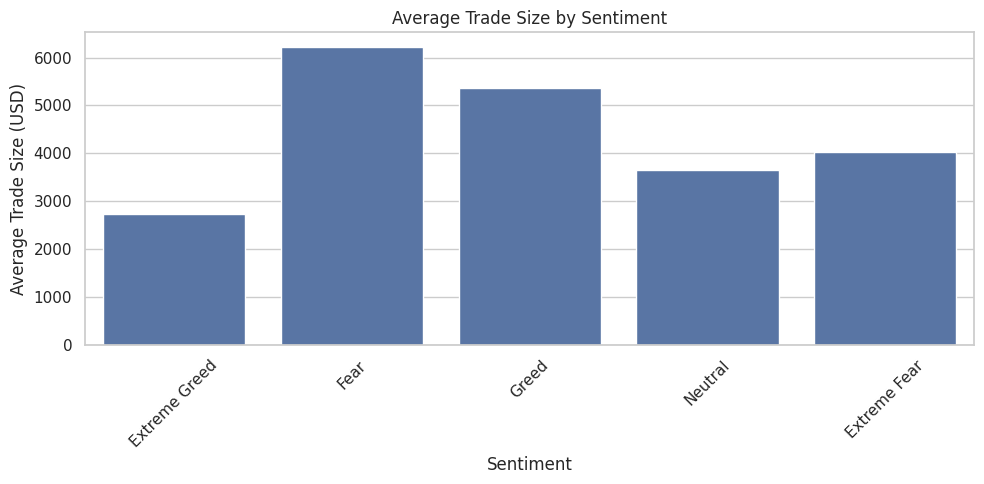

In [40]:
# Average trade size by sentiment
plt.figure(figsize=(10, 5))
sns.barplot(data=data, x="classification", y="abs_size_usd", estimator=np.mean, errorbar=None)
plt.title("Average Trade Size by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

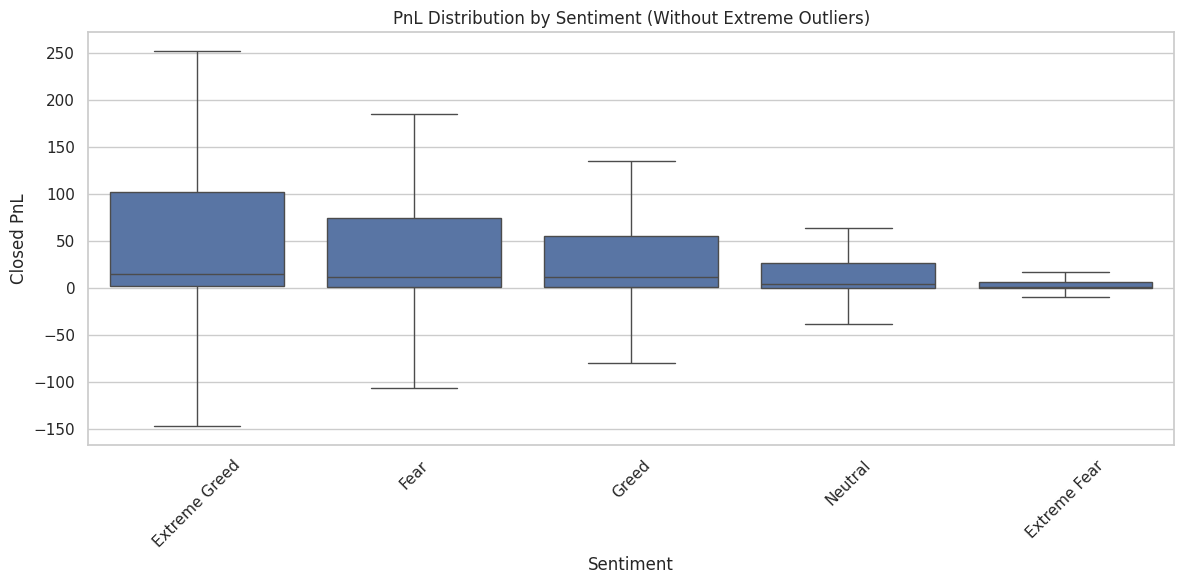

In [42]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data, x="classification", y="closed_pnl", showfliers=False)
plt.title("PnL Distribution by Sentiment (Without Extreme Outliers)")
plt.xlabel("Sentiment")
plt.ylabel("Closed PnL")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Advanced analysis

In [43]:
# Side performance by sentiment
side_perf = data.groupby(["classification", "side"]).agg(
    trades=("closed_pnl", "count"),
    total_pnl=("closed_pnl", "sum"),
    avg_pnl=("closed_pnl", "mean"),
    win_rate=("is_profit", "mean")
).reset_index()

side_perf["win_rate"] = side_perf["win_rate"] * 100
print(side_perf)

  classification  side  trades     total_pnl     avg_pnl   win_rate
0   Extreme Fear   buy     107 -3.794627e+03  -35.463806  68.224299
1   Extreme Fear  sell     716  8.194564e+03   11.444922  84.916201
2  Extreme Greed   buy     641  1.502716e+04   23.443304  80.655226
3  Extreme Greed  sell    2775  1.141867e+06  411.483430  93.441441
4           Fear   buy    2756  1.537586e+06  557.905002  89.731495
5           Fear  sell    3459  2.416394e+05   69.858166  81.584273
6          Greed   buy    2074  8.468078e+04   40.829691  77.386692
7          Greed  sell    3730  5.249518e+05  140.737736  88.873995
8        Neutral   buy     380  1.273396e+04   33.510420  87.631579
9        Neutral  sell    1291  6.192278e+04   47.964975  79.860573


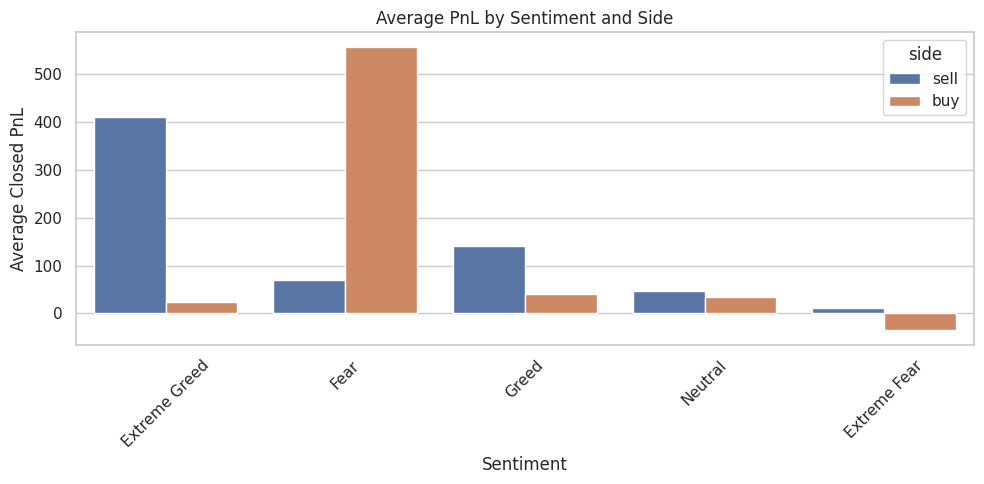

In [44]:
plt.figure(figsize=(10, 5))
sns.barplot(data=data, x="classification", y="closed_pnl", hue="side", estimator=np.mean, errorbar=None)
plt.title("Average PnL by Sentiment and Side")
plt.xlabel("Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:
# Top coin performance
top_coins = data.groupby("coin")["closed_pnl"].sum().nlargest(5).index

coin_data = data[data["coin"].isin(top_coins)].copy()

coin_summary = coin_data.groupby(["classification", "coin"]).agg(
    total_pnl=("closed_pnl", "sum"),
    avg_pnl=("closed_pnl", "mean"),
    trades=("closed_pnl", "count")
).reset_index()

print(coin_summary)

   classification  coin     total_pnl      avg_pnl  trades
0    Extreme Fear  @107  9.630259e+02    38.521038      25
1    Extreme Fear   BTC  5.677682e+03   141.942044      40
2    Extreme Fear  HYPE  1.359118e+03     2.280399     596
3    Extreme Fear   SOL  1.676526e+02    33.530514       5
4   Extreme Greed  @107  1.187084e+06   578.500894    2052
5   Extreme Greed   BTC  1.325809e+04   107.789384     123
6   Extreme Greed   ENA  2.333863e+00     1.166932       2
7   Extreme Greed  HYPE  3.367115e+02    10.203380      33
8   Extreme Greed   SOL  1.213837e+03    52.775502      23
9            Fear  @107  6.695034e+04   102.370553     654
10           Fear   BTC  5.350780e+04   155.545925     344
11           Fear   ENA  1.600313e+05  2051.683776      78
12           Fear  HYPE  2.491248e+05   150.075210    1660
13           Fear   SOL  8.264026e+05  1679.680048     492
14          Greed  @107  1.639184e+05   199.414144     822
15          Greed   BTC  2.567341e+04    43.148591     5

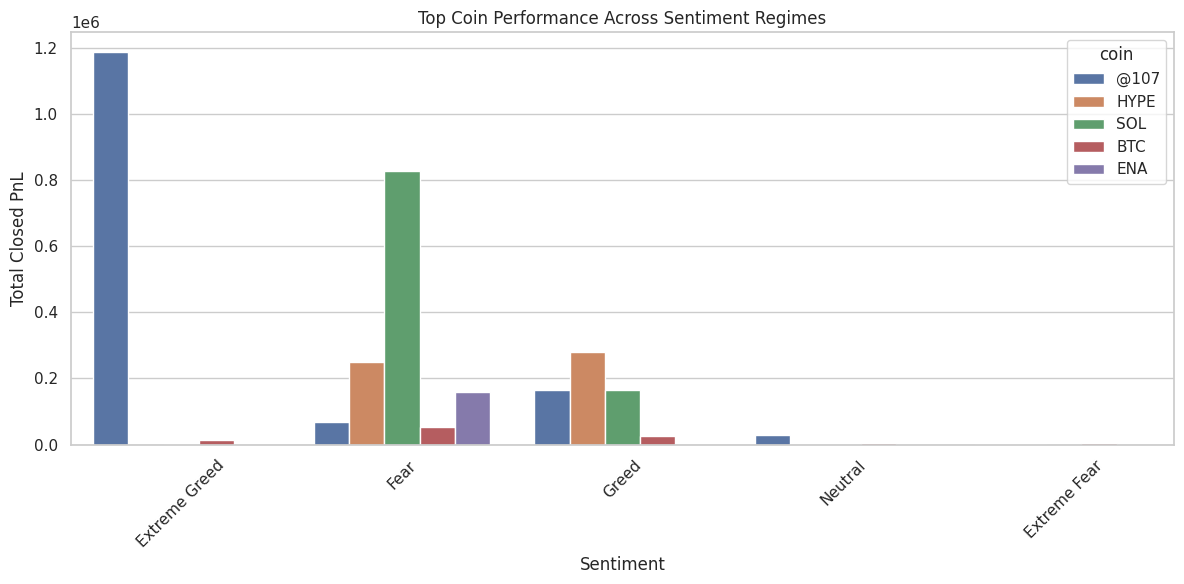

In [46]:
plt.figure(figsize=(12, 6))
sns.barplot(data=coin_data, x="classification", y="closed_pnl", hue="coin", estimator=sum, errorbar=None)
plt.title("Top Coin Performance Across Sentiment Regimes")
plt.xlabel("Sentiment")
plt.ylabel("Total Closed PnL")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

  classification  trade_count
0   Extreme Fear          823
1  Extreme Greed         3416
2           Fear         6215
3          Greed         5804
4        Neutral         1671


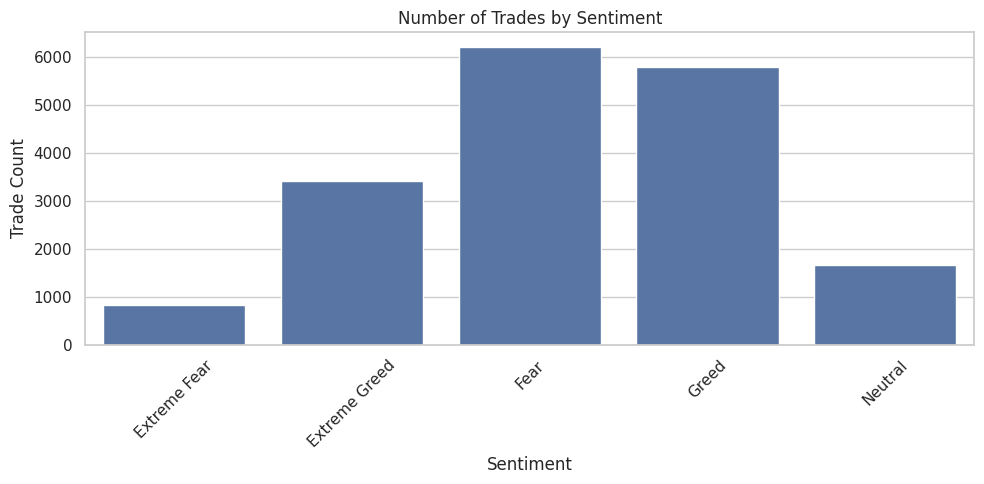

In [47]:
# Trade count by sentiment
trade_count = data.groupby("classification").size().reset_index(name="trade_count")
print(trade_count)

plt.figure(figsize=(10, 5))
sns.barplot(data=trade_count, x="classification", y="trade_count")
plt.title("Number of Trades by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Trade Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

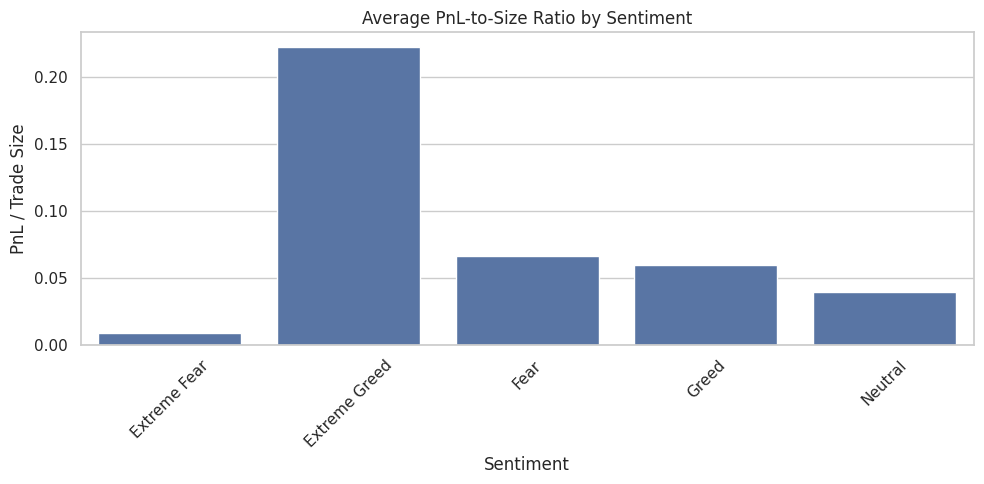

In [48]:
# Profitability efficiency: pnl relative to size
efficiency = data.groupby("classification")["pnl_to_size_ratio"].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=efficiency, x="classification", y="pnl_to_size_ratio")
plt.title("Average PnL-to-Size Ratio by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("PnL / Trade Size")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

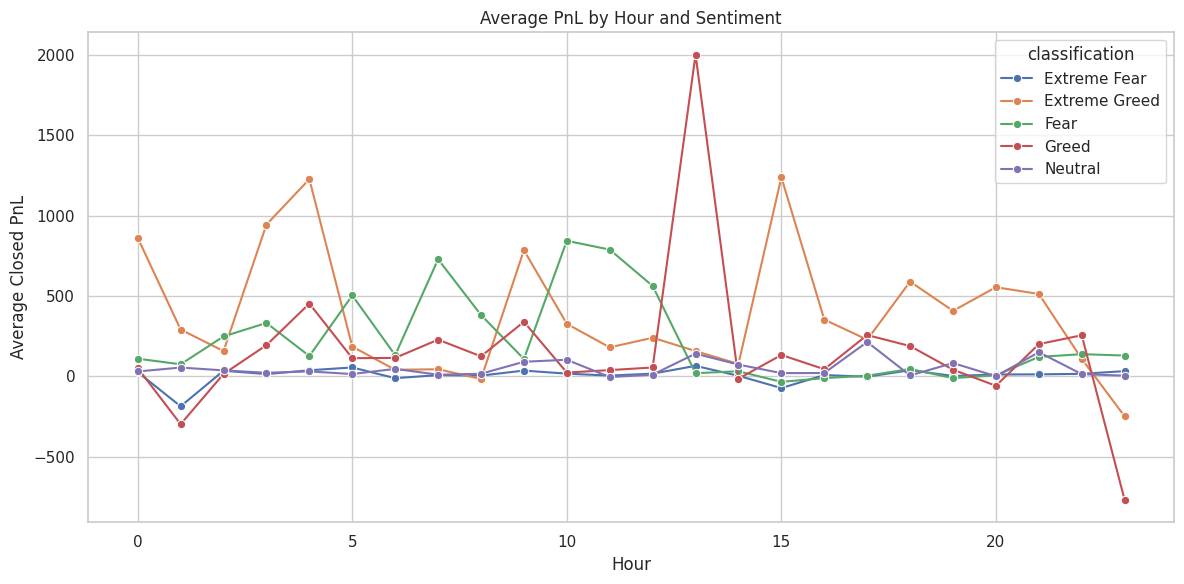

In [49]:
# Hourly behavior
hourly = data.groupby(["hour", "classification"])["closed_pnl"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly, x="hour", y="closed_pnl", hue="classification", marker="o")
plt.title("Average PnL by Hour and Sentiment")
plt.xlabel("Hour")
plt.ylabel("Average Closed PnL")
plt.tight_layout()
plt.show()

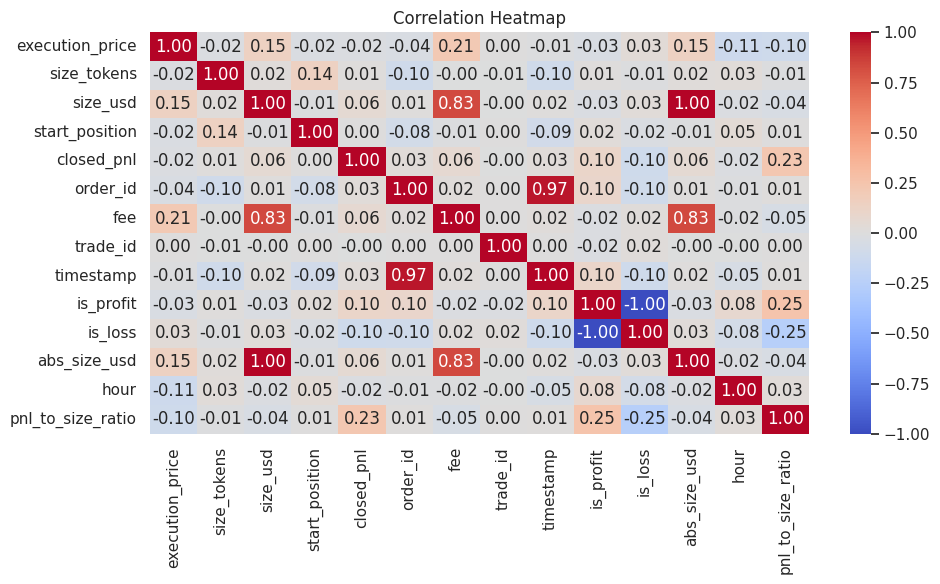

In [50]:
# Correlation heatmap
numeric_df = data.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

#### Statistical testing

In [51]:
# ANOVA / Kruskal-Wallis on PnL across sentiment groups
groups = [grp["closed_pnl"].dropna().values for _, grp in data.groupby("classification")]

if len(groups) > 1:
    anova_stat, anova_p = f_oneway(*groups)
    kruskal_stat, kruskal_p = kruskal(*groups)

    print("ANOVA statistic:", anova_stat)
    print("ANOVA p-value:", anova_p)
    print("Kruskal statistic:", kruskal_stat)
    print("Kruskal p-value:", kruskal_p)

ANOVA statistic: 15.959218558329844
ANOVA p-value: 4.77054055872701e-13
Kruskal statistic: 513.1844638253559
Kruskal p-value: 9.426323565469623e-110


In [52]:
final_table = data.groupby("classification").agg(
    trade_count=("closed_pnl", "count"),
    total_pnl=("closed_pnl", "sum"),
    avg_pnl=("closed_pnl", "mean"),
    median_pnl=("closed_pnl", "median"),
    win_rate_pct=("is_profit", lambda x: x.mean() * 100),
    avg_size_usd=("abs_size_usd", "mean"),
    pnl_efficiency=("pnl_to_size_ratio", "mean")
).round(2)

print(final_table)

                trade_count   total_pnl  avg_pnl  median_pnl  win_rate_pct  \
classification                                                               
Extreme Fear            823     4399.94     5.35        1.33         82.75   
Extreme Greed          3416  1156893.68   338.67       15.04         91.04   
Fear                   6215  1779225.58   286.28       11.95         85.20   
Greed                  5804   609632.53   105.04       12.22         84.77   
Neutral                1671    74656.74    44.68        4.53         81.63   

                avg_size_usd  pnl_efficiency  
classification                                
Extreme Fear         4023.29            0.01  
Extreme Greed        2730.72            0.22  
Fear                 6216.14            0.07  
Greed                5370.29            0.06  
Neutral              3649.99            0.04  
